In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [2]:
def load_data() -> dict[str, pd.DataFrame]:
    BASE = Path("..")
    data_dir = BASE / "data"
    if not data_dir.is_dir():
        raise FileNotFoundError(f"Data directory not found: {data_dir}")

    try:
        all_files = [
            f for f in data_dir.iterdir()
            if f.is_file() and str(f).__contains__(".csv")
        ]
    except OSError as exc:
        raise OSError(f"Could not list CSV files in {data_dir}") from exc

    for name in ("companies.csv", "combined_data.csv"):
        if not (data_dir / name).is_file():
            raise FileNotFoundError(f"Required CSV missing: {data_dir / name}")

    data_dict = {}
    for file in all_files:
        try:
            data_dict[file.name[:-4]] = pd.read_csv(file)
        except (OSError, pd.errors.ParserError) as exc:
            raise RuntimeError(f"Could not read CSV file: {file}") from exc

    return data_dict

## Data loading

The pipeline loads balance sheet, income statement, and cashflow tables, then combines them by company and fiscal year. Here I load the combined rows and each company's industry label.

In [3]:
data = load_data()

## Filtering and merging

The pipeline drops statement columns whose missing-to-observed ratio is not below 0.15. It requests annual US SimFin tables and joins the statements by `SimFinId` and `Fiscal Year`. The notebook then adds `IndustryId` by company.

In [4]:
companies_data = data["companies"][["SimFinId", "IndustryId"]]

combined_data = pd.merge(
    data["combined_data"],
    companies_data,
    on="SimFinId",
    how="inner",
)
combined_data = combined_data.set_index(["SimFinId"])

## Missing-value imputation

I fill missing values with company means first, then industry medians, and finally global medians. This starts with each company's own scale before falling back to broader groups.

In [5]:
combined_data = combined_data.groupby("SimFinId").transform(
    lambda x: x.fillna(x.mean())
)
# 
combined_data = combined_data.groupby("IndustryId").transform(
    lambda x: x.fillna(x.median())
)
# 
combined_data = combined_data.fillna(combined_data.median())
combined_data = combined_data.sort_values([combined_data.index.name, "Fiscal Year"])

In [6]:
print(combined_data.columns)
print(combined_data.isna().sum())

print("Duplicated Rows: ", combined_data.duplicated().sum())

combined_data = combined_data.drop_duplicates()
print("Duplicated Rows after drop: ", combined_data.duplicated().sum())

Index(['Fiscal Year', 'Cash, Cash Equivalents & Short Term Investments',
       'Total Current Assets', 'Property, Plant & Equipment, Net',
       'Other Long Term Assets', 'Total Noncurrent Assets', 'Total Assets',
       'Payables & Accruals', 'Total Current Liabilities',
       'Total Noncurrent Liabilities', 'Total Liabilities',
       'Share Capital & Additional Paid-In Capital', 'Retained Earnings',
       'Total Equity', 'Total Liabilities & Equity', 'Revenue',
       'Operating Expenses', 'Selling, General & Administrative',
       'Operating Income (Loss)', 'Non-Operating Income (Loss)',
       'Interest Expense, Net', 'Pretax Income (Loss), Adj.',
       'Pretax Income (Loss)', 'Income (Loss) from Continuing Operations',
       'Net Income', 'Net Income (Common)', 'Net Income/Starting Line',
       'Depreciation & Amortization', 'Non-Cash Items',
       'Change in Working Capital', 'Net Cash from Operating Activities',
       'Change in Fixed Assets & Intangibles',
       'Ne

## Prediction target

After sorting by company and fiscal year, `shift(-1)` lines up each row with that company's next reported Total Liabilities. I preserve missing next-year values as missing, then drop those rows so they are not labeled as debt decreases.

In [7]:

liabilities = combined_data.groupby("SimFinId")["Total Liabilities"].shift(-1)

combined_data["target"] = np.where(
    liabilities.isna(),
    np.nan,
    (liabilities > combined_data["Total Liabilities"])
)

combined_data = combined_data.dropna(subset=["target"])
combined_data["target"] = combined_data["target"].astype(int) 

In [8]:
combined_data.describe()

,Fiscal Year,"Cash, Cash Equivalents & Short Term Investments",Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Total Current Liabilities,Total Noncurrent Liabilities,...,Net Income/Starting Line,Depreciation & Amortization,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Net Cash from Financing Activities,Net Change in Cash,target
count,12345.000000,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,...,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,1.234500e+04,12345.000000
mean,2021.495909,1.174668e+09,3.624786e+09,2.619602e+09,3.493557e+09,6.560749e+09,1.018337e+10,1.122897e+09,2.266489e+09,4.345682e+09,...,4.164483e+08,3.913302e+08,1.695689e+08,-6.025862e+07,9.197455e+08,-3.939429e+08,-7.126349e+08,-1.628604e+08,6.849799e+07,0.586472
std,1.126553,8.280306e+09,5.309444e+10,1.582253e+10,1.891031e+10,3.399938e+10,6.824061e+10,5.408802e+09,1.084661e+10,5.399618e+10,...,4.145494e+09,7.227758e+09,3.596151e+09,2.624968e+09,1.149815e+10,5.974003e+09,1.408271e+10,9.653195e+09,2.525731e+09,0.492486
min,2020.000000,9.000000e+00,1.590000e+02,-1.575600e+10,-4.611310e+08,-1.505100e+10,1.590000e+02,4.880000e+02,8.050000e+02,-2.161009e+09,...,-2.560908e+11,-1.540000e+08,-7.825000e+10,-1.003951e+11,-7.293400e+10,-4.608300e+11,-1.045720e+12,-1.231170e+11,-9.761000e+10,0.000000
25%,2021.000000,3.189400e+07,9.641700e+07,7.132000e+06,1.751900e+07,4.690700e+07,2.075990e+08,1.569321e+07,2.653600e+07,2.046485e+07,...,-4.901900e+07,2.508000e+06,1.381000e+06,-3.770000e+07,-1.470900e+07,-9.722300e+07,-2.227610e+08,-1.077100e+08,-2.692400e+07,0.000000
50%,2021.000000,1.388137e+08,3.650040e+08,8.422000e+07,2.075010e+08,4.635930e+08,1.001571e+09,8.400000e+07,1.558960e+08,2.536020e+08,...,1.454758e+06,2.620000e+07,1.670500e+07,-2.209000e+06,3.553900e+07,-1.438600e+07,-3.645700e+07,6.200000e+04,1.457800e+06,1.000000
75%,2022.000000,4.592220e+08,1.424000e+09,7.209210e+08,1.343259e+09,2.772891e+09,4.580339e+09,4.410000e+08,8.371770e+08,1.697985e+09,...,1.610000e+08,1.346000e+08,7.503800e+07,6.935000e+06,3.405780e+08,-1.251000e+06,-7.810000e+05,6.194000e+07,5.562800e+07,1.000000
max,2024.000000,5.461640e+11,4.204337e+12,8.788560e+11,1.085553e+12,1.970691e+12,4.229166e+12,1.762480e+11,3.246790e+11,4.172623e+12,...,9.980300e+10,7.518230e+11,2.696878e+11,1.899670e+11,1.136210e+12,1.517800e+10,4.035177e+10,9.592170e+11,1.068050e+11,1.000000


## Time-based train/test split

I train on rows before 2023 and test on 2023 onward. The saved reports cover labeled 2023 and 2024 rows.

In [9]:
train = combined_data[combined_data["Fiscal Year"] < 2023]
test = combined_data[combined_data["Fiscal Year"] >= 2023]
if train.empty or test.empty:
    raise ValueError("Time-based split produced an empty train or test set")

In [10]:
train_features = train.drop(columns=["target"])
train_label = train["target"]
test_features = test.drop(columns=["target"])
test_label = test["target"]

## Logistic regression baseline

I use logistic regression as a simple baseline on one-year snapshots. `class_weight="balanced"` gives more weight to the less common class in the training data.

In [11]:
logr_model = LogisticRegression(max_iter=500, class_weight="balanced")
logr_model.fit(train_features, train_label)

/home/karan/Projects/FinFormer/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to 

In [12]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score
)

logr_y_hat = logr_model.predict(train_features)

logr_conf_matrix = confusion_matrix(y_pred=logr_y_hat, y_true=train_label)

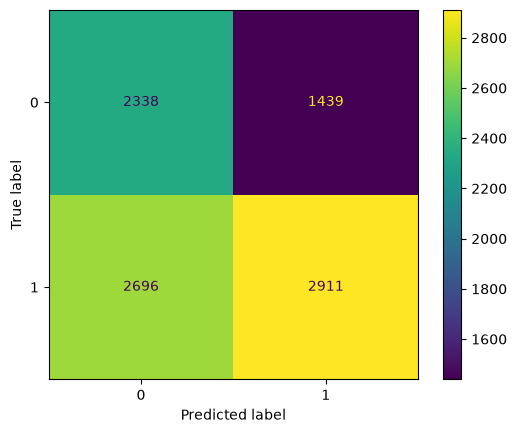

In [13]:
ConfusionMatrixDisplay(logr_conf_matrix).plot()

## Classification reports

I compare precision, recall, and F1 for both classes on the train and test rows. Class 1 means liabilities increased, so its recall shows how many actual increases the model catches.

In [14]:
pd.DataFrame(
    classification_report(train_label, logr_y_hat, output_dict=True)
).T

,precision,recall,f1-score,support
0,0.464442,0.619010,0.530700,3777.000000
1,0.669195,0.519172,0.584714,5607.000000
accuracy,0.559356,0.559356,0.559356,0.559356
macro avg,0.566819,0.569091,0.557707,9384.000000
weighted avg,0.586783,0.559356,0.562974,9384.000000


In [15]:
pd.DataFrame(
    classification_report(
        test_label, logr_model.predict(test_features), output_dict=True
    )
).T

,precision,recall,f1-score,support
0,0.489761,0.648343,0.558004,1328.000000
1,0.611804,0.450704,0.519041,1633.000000
accuracy,0.539345,0.539345,0.539345,0.539345
macro avg,0.550782,0.549524,0.538522,2961.000000
weighted avg,0.557068,0.539345,0.536516,2961.000000


On the test rows, logistic regression has 0.45 recall and 0.61 precision for debt increases, with 0.54 accuracy. Training recall is 0.52, a modest drop. The fit raised a convergence warning at 500 iterations, so treat these scores as provisional.

## XGBoost Baseline

This baseline uses boosted trees on the same single-year features. The reports below compare its training and test results.

In [16]:
from xgboost import XGBClassifier

In [17]:
xg_model = XGBClassifier(max_depth=3, objective="binary:logistic", eval_metric="logloss")

In [18]:
xg_model.fit(train_features, train_label)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


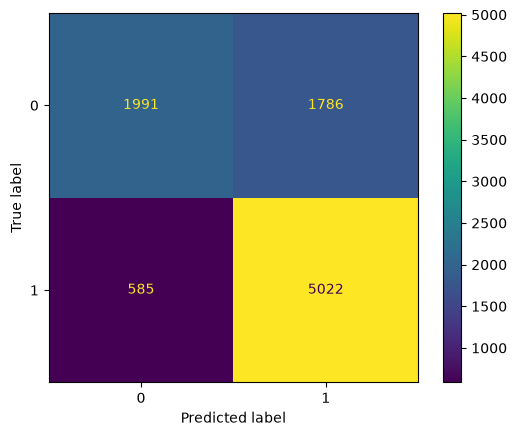

In [19]:
xg_y_hat = xg_model.predict(train_features)

conf_matrix = confusion_matrix(y_pred=xg_y_hat, y_true=train_label)
ConfusionMatrixDisplay(conf_matrix).plot()

In [20]:
pd.DataFrame(
    classification_report(train_label, xg_y_hat, output_dict=True)
).T

,precision,recall,f1-score,support
0,0.772904,0.527138,0.626790,3777.000000
1,0.737662,0.895666,0.809021,5607.000000
accuracy,0.747336,0.747336,0.747336,0.747336
macro avg,0.755283,0.711402,0.717906,9384.000000
weighted avg,0.751846,0.747336,0.735675,9384.000000


In [21]:
pd.DataFrame(
    classification_report(
        test_label, xg_model.predict(test_features), output_dict=True
    )
).T

,precision,recall,f1-score,support
0,0.558907,0.446536,0.496442,1328.000000
1,0.613158,0.713411,0.659496,1633.000000
accuracy,0.593718,0.593718,0.593718,0.593718
macro avg,0.586032,0.579974,0.577969,2961.000000
weighted avg,0.588826,0.593718,0.586367,2961.000000


On the test rows, XGBoost has 0.71 recall and 0.61 precision for debt increases, with 0.59 accuracy. It catches more increases than the saved logistic regression report, which has 0.45 recall. Its training recall is 0.90, so the drop on test rows suggests overfitting.

## Three-year sequence windows

For each company, I slide a three-year window along its labeled filings. Earlier windows train the model, and the latest window is held out. The label belongs to the final year in each window and asks whether liabilities increase in the following filing.

In [22]:
def create_windows(df, include_features, window_size=3):
    X, y, X_test, y_test = [], [], [], []

    for _, group in df.groupby("SimFinId"):
        group = group.sort_values("Fiscal Year")
        if len(group) < window_size + 1:
            continue

        feats = group[include_features].values
        targets = group["target"].values

        for end in range(window_size - 1, len(group) - 1):
            X.append(feats[end - window_size + 1 : end + 1])
            y.append(targets[end])

        X_test.append(feats[-window_size:])
        y_test.append(targets[-1])

    return np.array(X), np.array(y), np.array(X_test), np.array(y_test)

In [23]:
exclude_list = ["index", "Fiscal Year", "target", "SimFinId"]
include_list = [col for col in combined_data.columns if col not in exclude_list]

lstm_train, train_labels, lstm_test, test_labels = create_windows(combined_data, include_list)

I signed-log the values to reduce their range while keeping negative values, then standardize using training-window means and standard deviations. I apply those same statistics to the held-out windows.

In [24]:
import numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def slog(x):
    return np.sign(x) * np.log1p(np.abs(x))   

lstm_train, lstm_test = slog(lstm_train), slog(lstm_test)

F = lstm_train.shape[2]    
mean = lstm_train.reshape(-1, F).mean(axis=0)
std  = lstm_train.reshape(-1, F).std(axis=0) + 1e-8
lstm_train = (lstm_train - mean) / std
lstm_test  = (lstm_test  - mean) / std

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Xtr = torch.tensor(lstm_train, dtype=torch.float32)
ytr = torch.tensor(train_labels, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(lstm_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

## Old LSTM config

This version uses 16 hidden units, with no dropout or weight decay. I train it for 40 epochs in each of five runs.

In [26]:
class LSTMNet(nn.Module):
    
    def __init__(self, n_features, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

I repeat training with five seed values and collect accuracy, precision, and recall for both training and held-out windows. Each seed is now set before the model is initialized.

In [27]:
train_conf_old = {"Accuracy": [], "Precision": [], "Recall": []}
test_conf_old = {"Accuracy": [], "Precision": [], "Recall": []}
seeds = np.arange(5)
for seed in seeds:
   
    torch.manual_seed(seed)
    model = LSTMNet(F).to(device)
    pos_weight = torch.tensor((train_labels == 0).sum() / (train_labels == 1).sum()).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(40):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        # print(epoch, loss.item())
    
    model.eval()
    with torch.no_grad():
        logits = model(Xtr.to(device)).cpu().squeeze()
    preds = (torch.sigmoid(logits) > 0.5).int().numpy()
    print(classification_report(train_labels, preds))
    train_conf_old["Accuracy"].append(
        accuracy_score(y_pred=preds, y_true=train_labels)
    )
    train_conf_old["Precision"].append(
        precision_score(y_pred=preds, y_true=train_labels)
    )
    train_conf_old["Recall"].append(
        recall_score(y_pred=preds, y_true=train_labels)
    )

    model.eval()
    with torch.no_grad():
        logits = model(Xte.to(device)).cpu().squeeze()
    preds = (torch.sigmoid(logits) > 0.5).int().numpy()
    print(classification_report(test_labels, preds))
    test_conf_old["Accuracy"].append(
        accuracy_score(y_pred=preds, y_true=test_labels)
    )
    test_conf_old["Precision"].append(
        precision_score(y_pred=preds, y_true=test_labels)
    )
    test_conf_old["Recall"].append(
        recall_score(y_pred=preds, y_true=test_labels)
    )

              precision    recall  f1-score   support

           0       0.65      0.74      0.69      1055
           1       0.75      0.66      0.70      1225

    accuracy                           0.70      2280
   macro avg       0.70      0.70      0.70      2280
weighted avg       0.70      0.70      0.70      2280

              precision    recall  f1-score   support

           0       0.51      0.62      0.56      1026
           1       0.63      0.52      0.57      1254

    accuracy                           0.57      2280
   macro avg       0.57      0.57      0.57      2280
weighted avg       0.58      0.57      0.57      2280



              precision    recall  f1-score   support

           0       0.66      0.76      0.71      1055
           1       0.76      0.67      0.71      1225

    accuracy                           0.71      2280
   macro avg       0.71      0.71      0.71      2280
weighted avg       0.71      0.71      0.71      2280

              precision    recall  f1-score   support

           0       0.51      0.64      0.57      1026
           1       0.63      0.50      0.56      1254

    accuracy                           0.57      2280
   macro avg       0.57      0.57      0.57      2280
weighted avg       0.58      0.57      0.57      2280



              precision    recall  f1-score   support

           0       0.68      0.72      0.70      1055
           1       0.74      0.70      0.72      1225

    accuracy                           0.71      2280
   macro avg       0.71      0.71      0.71      2280
weighted avg       0.71      0.71      0.71      2280

              precision    recall  f1-score   support

           0       0.52      0.58      0.54      1026
           1       0.62      0.56      0.59      1254

    accuracy                           0.57      2280
   macro avg       0.57      0.57      0.57      2280
weighted avg       0.57      0.57      0.57      2280



              precision    recall  f1-score   support

           0       0.67      0.73      0.70      1055
           1       0.75      0.70      0.72      1225

    accuracy                           0.71      2280
   macro avg       0.71      0.71      0.71      2280
weighted avg       0.72      0.71      0.71      2280

              precision    recall  f1-score   support

           0       0.53      0.61      0.56      1026
           1       0.63      0.55      0.59      1254

    accuracy                           0.58      2280
   macro avg       0.58      0.58      0.58      2280
weighted avg       0.58      0.58      0.58      2280



              precision    recall  f1-score   support

           0       0.66      0.77      0.71      1055
           1       0.77      0.66      0.71      1225

    accuracy                           0.71      2280
   macro avg       0.71      0.71      0.71      2280
weighted avg       0.72      0.71      0.71      2280

              precision    recall  f1-score   support

           0       0.51      0.64      0.57      1026
           1       0.63      0.50      0.56      1254

    accuracy                           0.56      2280
   macro avg       0.57      0.57      0.56      2280
weighted avg       0.58      0.56      0.56      2280



## New LSTM config

This version also uses 16 hidden units and 40 epochs. It adds 0.3 dropout and 0.001 weight decay.

In [28]:
class LSTMNet(nn.Module):
    
    def __init__(self, n_features, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.drop(h[-1]))

model = LSTMNet(F).to(device)

I use the same five seed values for this config so I can compare its score averages and variation with the old config.

In [29]:
train_conf_new = {"Accuracy": [], "Precision": [], "Recall": []}
test_conf_new = {"Accuracy": [], "Precision": [], "Recall": []}
for seed in seeds:
   
    torch.manual_seed(seed)
    model = LSTMNet(F).to(device)
    pos_weight = torch.tensor((train_labels == 0).sum() / (train_labels == 1).sum()).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    for epoch in range(40):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        #print(epoch, loss.item())
    
    model.eval()
    with torch.no_grad():
        logits = model(Xtr.to(device)).cpu().squeeze()
    preds = (torch.sigmoid(logits) > 0.5).int().numpy()
    print(classification_report(train_labels, preds))
    train_conf_new["Accuracy"].append(
        accuracy_score(y_pred=preds, y_true=train_labels)
    )
    train_conf_new["Precision"].append(
        precision_score(y_pred=preds, y_true=train_labels)
    )
    train_conf_new["Recall"].append(
        recall_score(y_pred=preds, y_true=train_labels)
    )

    model.eval()
    with torch.no_grad():
        logits = model(Xte.to(device)).cpu().squeeze()
    preds = (torch.sigmoid(logits) > 0.5).int().numpy()
    print(classification_report(test_labels, preds))
    
    test_conf_new["Accuracy"].append(
        accuracy_score(y_pred=preds, y_true=test_labels)
    )
    test_conf_new["Precision"].append(
        precision_score(y_pred=preds, y_true=test_labels)
    )
    test_conf_new["Recall"].append(
        recall_score(y_pred=preds, y_true=test_labels)
    )

              precision    recall  f1-score   support

           0       0.60      0.67      0.63      1055
           1       0.68      0.62      0.65      1225

    accuracy                           0.64      2280
   macro avg       0.64      0.64      0.64      2280
weighted avg       0.65      0.64      0.64      2280

              precision    recall  f1-score   support

           0       0.51      0.65      0.57      1026
           1       0.63      0.49      0.55      1254

    accuracy                           0.56      2280
   macro avg       0.57      0.57      0.56      2280
weighted avg       0.58      0.56      0.56      2280



              precision    recall  f1-score   support

           0       0.59      0.69      0.64      1055
           1       0.69      0.59      0.64      1225

    accuracy                           0.64      2280
   macro avg       0.64      0.64      0.64      2280
weighted avg       0.64      0.64      0.64      2280

              precision    recall  f1-score   support

           0       0.51      0.66      0.57      1026
           1       0.63      0.48      0.55      1254

    accuracy                           0.56      2280
   macro avg       0.57      0.57      0.56      2280
weighted avg       0.58      0.56      0.56      2280



              precision    recall  f1-score   support

           0       0.60      0.67      0.63      1055
           1       0.68      0.61      0.65      1225

    accuracy                           0.64      2280
   macro avg       0.64      0.64      0.64      2280
weighted avg       0.65      0.64      0.64      2280

              precision    recall  f1-score   support

           0       0.51      0.62      0.56      1026
           1       0.62      0.51      0.56      1254

    accuracy                           0.56      2280
   macro avg       0.57      0.57      0.56      2280
weighted avg       0.57      0.56      0.56      2280



              precision    recall  f1-score   support

           0       0.60      0.69      0.65      1055
           1       0.70      0.61      0.65      1225

    accuracy                           0.65      2280
   macro avg       0.65      0.65      0.65      2280
weighted avg       0.65      0.65      0.65      2280

              precision    recall  f1-score   support

           0       0.50      0.61      0.55      1026
           1       0.61      0.51      0.56      1254

    accuracy                           0.55      2280
   macro avg       0.56      0.56      0.55      2280
weighted avg       0.56      0.55      0.55      2280



              precision    recall  f1-score   support

           0       0.59      0.70      0.64      1055
           1       0.70      0.59      0.64      1225

    accuracy                           0.64      2280
   macro avg       0.64      0.64      0.64      2280
weighted avg       0.65      0.64      0.64      2280

              precision    recall  f1-score   support

           0       0.51      0.65      0.57      1026
           1       0.63      0.48      0.55      1254

    accuracy                           0.56      2280
   macro avg       0.57      0.57      0.56      2280
weighted avg       0.58      0.56      0.56      2280



In [30]:
print("OLD config\n")

for metric in ["Accuracy","Precision","Recall"]:
    
    print(metric,"\n")
    print(f"Mean Train {metric}: ",np.mean(train_conf_old[metric]))
    print(f"Mean Test {metric}: ",np.mean(test_conf_old[metric]))
    print(f"Standard Deviation Train {metric}: ",np.std(train_conf_old[metric]))
    print(f"Standard Deviation Test {metric}: ",np.std(test_conf_old[metric]))
    print()

OLD config

Accuracy 

Mean Train Accuracy:  0.7071052631578947
Mean Test Accuracy:  0.5679824561403509
Standard Deviation Train Accuracy:  0.005734722501291635
Standard Deviation Test Accuracy:  0.004666468799393113

Precision 

Mean Train Precision:  0.7535460832645932
Mean Test Precision:  0.6277969599890743
Standard Deviation Train Precision:  0.008964068307811133
Standard Deviation Test Precision:  0.005962983463770467

Recall 

Mean Train Recall:  0.6764081632653061
Mean Test Recall:  0.5275917065390751
Standard Deviation Train Recall:  0.020304061017300278
Standard Deviation Test Recall:  0.023659361141775134



In [31]:
print("NEW config\n")

for metric in ["Accuracy","Precision","Recall"]:
    
    print(metric,"\n")
    print(f"Mean Train {metric}: ",np.mean(train_conf_new[metric]))
    print(f"Mean Test {metric}: ",np.mean(test_conf_new[metric]))
    print(f"Standard Deviation Train {metric}: ",np.std(train_conf_new[metric]))
    print(f"Standard Deviation Test {metric}: ",np.std(test_conf_new[metric]))
    print()

NEW config

Accuracy 

Mean Train Accuracy:  0.641140350877193
Mean Test Accuracy:  0.559298245614035
Standard Deviation Train Accuracy:  0.003446821527085709
Standard Deviation Test Accuracy:  0.003018359742821941

Precision 

Mean Train Precision:  0.6901867994324713
Mean Test Precision:  0.6256981241191301
Standard Deviation Train Precision:  0.005268253583942644
Standard Deviation Test Precision:  0.0064103052275500064

Recall 

Mean Train Recall:  0.6027755102040817
Mean Test Recall:  0.4952153110047847
Standard Deviation Train Recall:  0.011643460786726817
Standard Deviation Test Recall:  0.012779091307183504



The five-run summaries show average scores and standard deviations for each LSTM config. I use these averages below rather than relying on a single run.

## XGBoost on the same windows

I flatten each three-year window into 102 features and fit XGBoost once. It uses the default settings except for `scale_pos_weight`, which accounts for the class balance.

In [32]:
Xtr_flat = lstm_train.reshape(len(lstm_train), -1)
Xte_flat = lstm_test.reshape(len(lstm_test), -1)

xgb = XGBClassifier(scale_pos_weight=(train_labels == 0).sum() / (train_labels== 1).sum())
xgb.fit(Xtr_flat, train_labels)
print(classification_report(test_labels, xgb.predict(Xte_flat)))

              precision    recall  f1-score   support

           0       0.54      0.53      0.53      1026
           1       0.62      0.62      0.62      1254

    accuracy                           0.58      2280
   macro avg       0.58      0.58      0.58      2280
weighted avg       0.58      0.58      0.58      2280



On these held-out windows, XGBoost has 0.62 recall and 0.62 precision for debt increases, with 0.58 accuracy. This is one run.

Across five runs, the old LSTM averages 0.568 test accuracy and 0.528 recall for debt increases. The regularized config averages 0.559 accuracy and 0.495 recall. XGBoost gets 0.58 accuracy and 0.62 recall on the same windows in one run. The scores are close to the 0.55 always-positive accuracy baseline, and XGBoost catches more increases in this run.